# Satellite Image Classification


In [1]:
!pip install -q torchinfo torchview

In [4]:
import os
import time
import random
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset, Dataset

import torchvision
from torchvision import transforms, datasets, models
from transformers import CLIPProcessor, CLIPModel

from torchinfo import summary
from torchview import draw_graph
from IPython.display import Image, display

from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay

from collections import Counter, defaultdict
from tqdm import tqdm

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [6]:
def reproducibility(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    print(f"Random seed set to {seed}")


reproducibility()

Random seed set to 42


## 0: Dataset and Preprocessing


In [7]:
base_transform = transforms.Compose([transforms.ToTensor()])

eurosat_data = datasets.EuroSAT(root="./data", download=True, transform=base_transform)

100%|██████████| 94.3M/94.3M [00:00<00:00, 349MB/s]


In [8]:
num_images = len(eurosat_data)
class_names = eurosat_data.classes
num_classes = len(eurosat_data.classes)
img_shape = eurosat_data[0][0].shape

print(f"Total images: {num_images}")
print(f"Total classes: {num_classes}")
print(f"Classes: {class_names}")
print(f"Image shape: {img_shape}")

Total images: 27000
Total classes: 10
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Image shape: torch.Size([3, 64, 64])


In [9]:
train_transform = transforms.Compose(
    [
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(90),
        transforms.RandomResizedCrop(64, scale=(0.8, 1.0)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

val_test_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

In [10]:
class_indices = defaultdict(list)

for idx, (_, label) in enumerate(eurosat_data):
    class_indices[label].append(idx)

train_full_idx = []
train_10shot_idx = []
train_5shot_idx = []
val_idx = []
test_idx = []

for label, indices in class_indices.items():
    random.shuffle(indices)
    n = len(indices)
    n_train = int(0.7 * n)
    n_val = int(0.15 * n)
    train_indices = indices[:n_train]
    val_indices = indices[n_train : n_train + n_val]
    test_indices = indices[n_train + n_val :]
    train_full_idx.extend(train_indices)
    val_idx.extend(val_indices)
    test_idx.extend(test_indices)
    train_10shot_idx.extend(train_indices[:10])
    train_5shot_idx.extend(train_indices[:5])

train_full = Subset(
    datasets.EuroSAT(root="./data", transform=train_transform),
    train_full_idx,
)
train_10shot = Subset(
    datasets.EuroSAT(root="./data", transform=train_transform),
    train_10shot_idx,
)
train_5shot = Subset(
    datasets.EuroSAT(root="./data", transform=train_transform),
    train_5shot_idx,
)
val_set = Subset(
    datasets.EuroSAT(root="./data", transform=val_test_transform),
    val_idx,
)
test_set = Subset(
    datasets.EuroSAT(root="./data", transform=val_test_transform),
    test_idx,
)

splits = {
    "Train full": train_full,
    "Train 10-shot": train_10shot,
    "Train 5-shot": train_5shot,
    "Validation": val_set,
    "Test": test_set,
}

for name, split in splits.items():
    labels = [label for _, label in split]
    counts = Counter(labels)
    print(f"\n{name}")
    print(f"Total samples: {len(split)}")
    for cls_id, cls_name in enumerate(class_names):
        print(f"    {cls_name}: {counts.get(cls_id, 0)}")


Train full
Total samples: 18900
    AnnualCrop: 2100
    Forest: 2100
    HerbaceousVegetation: 2100
    Highway: 1750
    Industrial: 1750
    Pasture: 1400
    PermanentCrop: 1750
    Residential: 2100
    River: 1750
    SeaLake: 2100

Train 10-shot
Total samples: 100
    AnnualCrop: 10
    Forest: 10
    HerbaceousVegetation: 10
    Highway: 10
    Industrial: 10
    Pasture: 10
    PermanentCrop: 10
    Residential: 10
    River: 10
    SeaLake: 10

Train 5-shot
Total samples: 50
    AnnualCrop: 5
    Forest: 5
    HerbaceousVegetation: 5
    Highway: 5
    Industrial: 5
    Pasture: 5
    PermanentCrop: 5
    Residential: 5
    River: 5
    SeaLake: 5

Validation
Total samples: 4050
    AnnualCrop: 450
    Forest: 450
    HerbaceousVegetation: 450
    Highway: 375
    Industrial: 375
    Pasture: 300
    PermanentCrop: 375
    Residential: 450
    River: 375
    SeaLake: 450

Test
Total samples: 4050
    AnnualCrop: 450
    Forest: 450
    HerbaceousVegetation: 450
    Highway: 

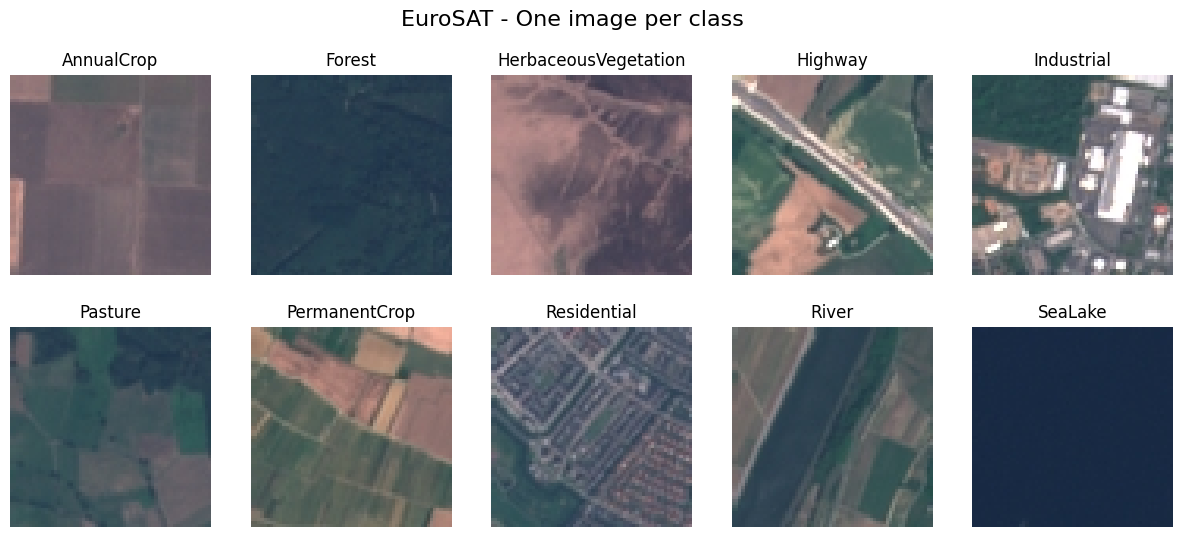

In [9]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

for cls in range(num_classes):
    for img, label in eurosat_data:
        if label == cls:
            axes[cls].imshow(img.permute(1, 2, 0))
            axes[cls].set_title(class_names[cls])
            axes[cls].axis("off")
            break

plt.suptitle("EuroSAT - One image per class", fontsize=16)
plt.show()

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


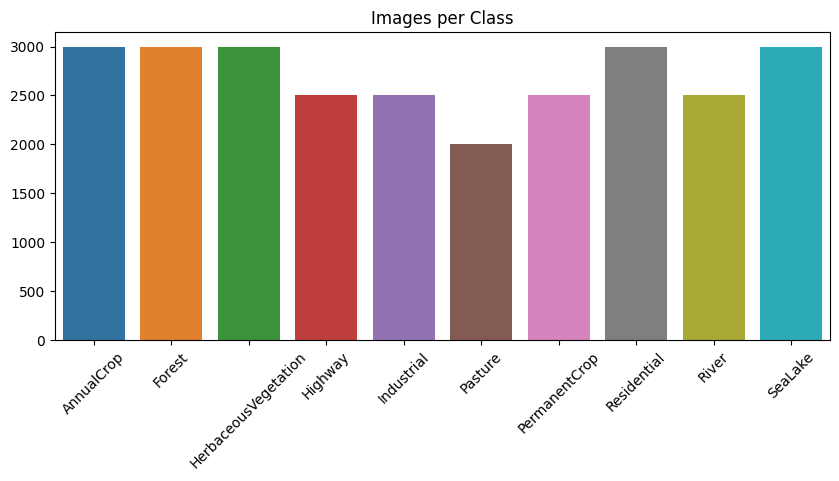

In [10]:
counts = [len(class_indices[c]) for c in range(num_classes)]
plt.figure(figsize=(10, 4))
sns.barplot(x=class_names, y=counts)
plt.xticks(rotation=45)
plt.title("Images per Class")
plt.show()

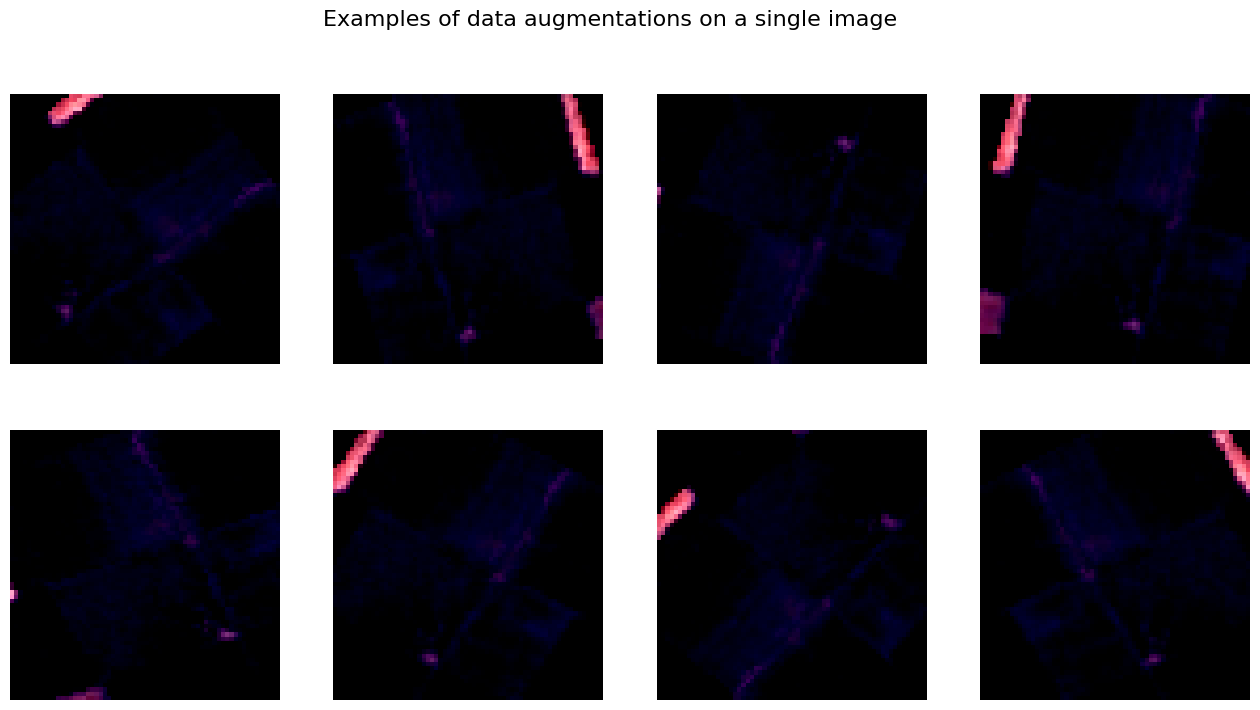

In [11]:
img, _ = eurosat_data[0]
pil_img = transforms.ToPILImage()(img)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(8):
    aug_img = train_transform(pil_img)
    axes[i].imshow(aug_img.permute(1, 2, 0).clamp(0, 1))
    axes[i].axis("off")

plt.suptitle("Examples of data augmentations on a single image", fontsize=16)
plt.show()

## 1: Baseline and Transfer Learning


### Task 1.1 - Baseline CNN from scratch


In [11]:
def train_per_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            total_loss += loss.item() * x.size(0)
            preds = logits.argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
            all_preds.append(preds.cpu())
            all_labels.append(y.cpu())

    acc = correct / total
    loss = total_loss / total
    y_true = torch.cat(all_labels).numpy()
    y_pred = torch.cat(all_preds).numpy()
    cm = confusion_matrix(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="macro")

    return loss, acc, cm, f1


def train_model(
    model,
    train_loader,
    val_loader,
    test_loader,
    optimizer,
    criterion,
    num_epochs,
    patience=3,
):
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    epochs_no_improve = 0

    start_time = time.time()

    for epoch in range(num_epochs):
        train_loss, train_acc = train_per_epoch(
            model, train_loader, optimizer, criterion
        )
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        print(
            f"Epoch {epoch+1}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
            best_epoch = epoch + 1
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(
                f"Early stopping triggered at epoch {epoch+1} "
                f"(best val loss: {best_val_loss:.4f})"
            )
            break

    model.load_state_dict(best_state)
    training_time = time.time() - start_time
    test_loss, test_acc, test_cm, test_f1 = evaluate(model, test_loader, criterion)
    print(f"Test Accuracy: {test_acc * 100:.2f}%")
    print(f"Training Time: {training_time / 60:.2f} minutes")

    return {
        "best_epoch": best_epoch,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs,
        "test_loss": test_loss,
        "test_acc": test_acc,
        "test_f1": test_f1,
        "confusion_matrix": test_cm,
        "training_time": training_time,
    }


def plot_train_curves(results, title=""):
    best_epoch = results["best_epoch"]
    epochs = range(1, len(results["train_losses"]) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, results["train_losses"], label="Train Loss")
    plt.plot(epochs, results["val_losses"], label="Val Loss")
    plt.axvline(best_epoch, linestyle="--", color="gray", label="Best Epoch")
    plt.legend()
    plt.title(f"Loss Curves - {title}")

    plt.subplot(1, 2, 2)
    plt.plot(epochs, results["train_accs"], label="Train Acc")
    plt.plot(epochs, results["val_accs"], label="Val Acc")
    plt.axvline(best_epoch, linestyle="--", color="gray", label="Best Epoch")
    plt.legend()
    plt.title(f"Accuracy Curves - {title}")

    plt.show()


def plot_confusion_matrix(cm, class_names, title=""):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names,
    )
    fig, ax = plt.subplots(figsize=(6, 6))
    disp.plot(cmap="Blues", values_format="d", ax=ax, xticks_rotation="vertical")
    plt.title(f"Confusion Matrix - {title}")
    plt.show()

In [24]:
batch_size = 32

train_loader = DataLoader(
    train_full, batch_size=batch_size, shuffle=True, num_workers=2
)
val_loader = DataLoader(val_set, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False, num_workers=2)

In [30]:
class CNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN(num_classes).to(device)
summary(model, input_size=(1, 3, 64, 64), device=device)

Layer (type:depth-idx)                   Output Shape              Param #
CNN                                      [1, 10]                   --
├─Sequential: 1-1                        [1, 128, 8, 8]            --
│    └─Conv2d: 2-1                       [1, 32, 64, 64]           896
│    └─BatchNorm2d: 2-2                  [1, 32, 64, 64]           64
│    └─ReLU: 2-3                         [1, 32, 64, 64]           --
│    └─MaxPool2d: 2-4                    [1, 32, 32, 32]           --
│    └─Conv2d: 2-5                       [1, 64, 32, 32]           18,496
│    └─BatchNorm2d: 2-6                  [1, 64, 32, 32]           128
│    └─ReLU: 2-7                         [1, 64, 32, 32]           --
│    └─MaxPool2d: 2-8                    [1, 64, 16, 16]           --
│    └─Conv2d: 2-9                       [1, 128, 16, 16]          73,856
│    └─BatchNorm2d: 2-10                 [1, 128, 16, 16]          256
│    └─ReLU: 2-11                        [1, 128, 16, 16]          --
│   

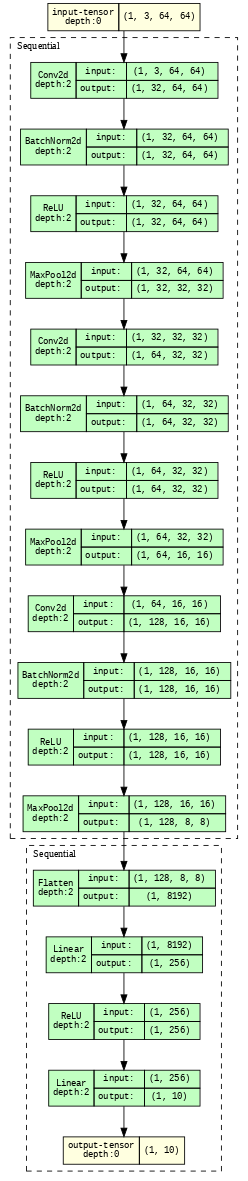

In [11]:
model_graph = draw_graph(
    model, input_size=(1, 3, 64, 64), expand_nested=True, device=device
)
model_graph.visual_graph.render("baseline_cnn", format="png")
display(Image("baseline_cnn.png"))

In [44]:
reproducibility()
cnn = CNN(num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(cnn.parameters(), lr=1e-3)

results_cnn = train_model(
    model=cnn,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=12,
)

Random seed set to 42
Epoch 1/12 | Train Loss: 1.0501, Train Acc: 0.6241 | Val Loss: 0.8174, Val Acc: 0.6921
Epoch 2/12 | Train Loss: 0.7515, Train Acc: 0.7244 | Val Loss: 0.6353, Val Acc: 0.7864
Epoch 3/12 | Train Loss: 0.6692, Train Acc: 0.7566 | Val Loss: 0.6247, Val Acc: 0.7874
Epoch 4/12 | Train Loss: 0.6042, Train Acc: 0.7838 | Val Loss: 0.5419, Val Acc: 0.8109
Epoch 5/12 | Train Loss: 0.5567, Train Acc: 0.8067 | Val Loss: 0.6433, Val Acc: 0.7916
Epoch 6/12 | Train Loss: 0.5070, Train Acc: 0.8188 | Val Loss: 0.4728, Val Acc: 0.8375
Epoch 7/12 | Train Loss: 0.4704, Train Acc: 0.8335 | Val Loss: 0.4627, Val Acc: 0.8496
Epoch 8/12 | Train Loss: 0.4438, Train Acc: 0.8419 | Val Loss: 0.5344, Val Acc: 0.8405
Epoch 9/12 | Train Loss: 0.4210, Train Acc: 0.8523 | Val Loss: 0.4237, Val Acc: 0.8511
Epoch 10/12 | Train Loss: 0.3933, Train Acc: 0.8606 | Val Loss: 0.3739, Val Acc: 0.8677
Epoch 11/12 | Train Loss: 0.3889, Train Acc: 0.8629 | Val Loss: 0.3433, Val Acc: 0.8805
Epoch 12/12 | Train

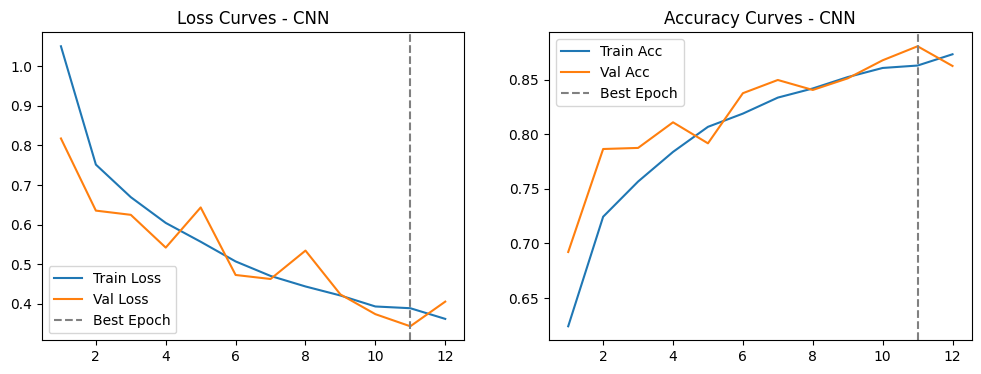

In [45]:
plot_train_curves(results_cnn, "CNN")

### Task 1.2 - Transfer Learning


In [31]:
resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
resnet50.fc = nn.Linear(resnet50.fc.in_features, num_classes)
resnet50 = resnet50.to(device)
summary(resnet50, input_size=(1, 3, 64, 64), device=device)

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 10]                   --
├─Conv2d: 1-1                            [1, 64, 32, 32]           9,408
├─BatchNorm2d: 1-2                       [1, 64, 32, 32]           128
├─ReLU: 1-3                              [1, 64, 32, 32]           --
├─MaxPool2d: 1-4                         [1, 64, 16, 16]           --
├─Sequential: 1-5                        [1, 256, 16, 16]          --
│    └─Bottleneck: 2-1                   [1, 256, 16, 16]          --
│    │    └─Conv2d: 3-1                  [1, 64, 16, 16]           4,096
│    │    └─BatchNorm2d: 3-2             [1, 64, 16, 16]           128
│    │    └─ReLU: 3-3                    [1, 64, 16, 16]           --
│    │    └─Conv2d: 3-4                  [1, 64, 16, 16]           36,864
│    │    └─BatchNorm2d: 3-5             [1, 64, 16, 16]           128
│    │    └─ReLU: 3-6                    [1, 64, 16, 16]           --
│ 

In [32]:
reproducibility()

resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
resnet50.fc = nn.Linear(resnet50.fc.in_features, num_classes)
resnet50 = resnet50.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(resnet50.parameters(), 1e-3)

results_resnet50 = train_model(
    model=resnet50,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=15,
)

Random seed set to 42
Epoch 1/15 | Train Loss: 0.5082, Train Acc: 0.8426 | Val Loss: 0.2661, Val Acc: 0.9202
Epoch 2/15 | Train Loss: 0.3144, Train Acc: 0.9017 | Val Loss: 0.2126, Val Acc: 0.9267
Epoch 3/15 | Train Loss: 0.2626, Train Acc: 0.9128 | Val Loss: 0.1888, Val Acc: 0.9321
Epoch 4/15 | Train Loss: 0.2352, Train Acc: 0.9216 | Val Loss: 0.1727, Val Acc: 0.9425
Epoch 5/15 | Train Loss: 0.2092, Train Acc: 0.9308 | Val Loss: 0.1462, Val Acc: 0.9556
Epoch 6/15 | Train Loss: 0.2058, Train Acc: 0.9319 | Val Loss: 0.1332, Val Acc: 0.9541
Epoch 7/15 | Train Loss: 0.1862, Train Acc: 0.9388 | Val Loss: 0.1423, Val Acc: 0.9533
Epoch 8/15 | Train Loss: 0.1803, Train Acc: 0.9399 | Val Loss: 0.1701, Val Acc: 0.9437
Epoch 9/15 | Train Loss: 0.1773, Train Acc: 0.9420 | Val Loss: 0.3709, Val Acc: 0.8760
Early stopping triggered at epoch 9 (best val loss: 0.1332)
Test Accuracy: 95.21%
Training Time: 6.14 minutes


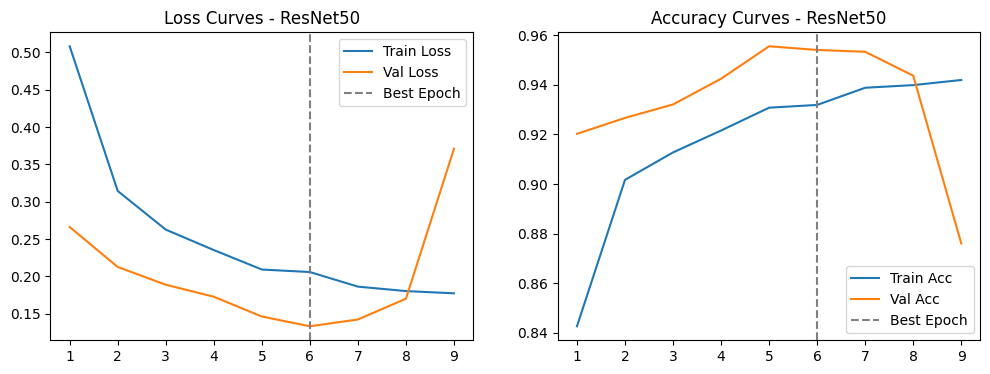

In [38]:
plot_train_curves(results_resnet50, "ResNet50")

In [32]:
resnet50_frozen = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
for param in resnet50_frozen.parameters():
    param.requires_grad = False
resnet50_frozen.fc = nn.Linear(resnet50_frozen.fc.in_features, num_classes)
resnet50_frozen = resnet50_frozen.to(device)
summary(resnet50_frozen, input_size=(1, 3, 64, 64), device=device)

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 10]                   --
├─Conv2d: 1-1                            [1, 64, 32, 32]           (9,408)
├─BatchNorm2d: 1-2                       [1, 64, 32, 32]           (128)
├─ReLU: 1-3                              [1, 64, 32, 32]           --
├─MaxPool2d: 1-4                         [1, 64, 16, 16]           --
├─Sequential: 1-5                        [1, 256, 16, 16]          --
│    └─Bottleneck: 2-1                   [1, 256, 16, 16]          --
│    │    └─Conv2d: 3-1                  [1, 64, 16, 16]           (4,096)
│    │    └─BatchNorm2d: 3-2             [1, 64, 16, 16]           (128)
│    │    └─ReLU: 3-3                    [1, 64, 16, 16]           --
│    │    └─Conv2d: 3-4                  [1, 64, 16, 16]           (36,864)
│    │    └─BatchNorm2d: 3-5             [1, 64, 16, 16]           (128)
│    │    └─ReLU: 3-6                    [1, 64, 16, 16]    

In [34]:
reproducibility()

resnet50_frozen = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
for param in resnet50_frozen.parameters():
    param.requires_grad = False
resnet50_frozen.fc = nn.Linear(resnet50_frozen.fc.in_features, num_classes)
resnet50_frozen = resnet50_frozen.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(resnet50_frozen.parameters(), 1e-3)

results_resnet50_frozen = train_model(
    model=resnet50_frozen,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=12,
)

Random seed set to 42
Epoch 1/12 | Train Loss: 1.0310, Train Acc: 0.6957 | Val Loss: 0.7348, Val Acc: 0.7812
Epoch 2/12 | Train Loss: 0.7315, Train Acc: 0.7696 | Val Loss: 0.6367, Val Acc: 0.8062
Epoch 3/12 | Train Loss: 0.6719, Train Acc: 0.7833 | Val Loss: 0.5612, Val Acc: 0.8230
Epoch 4/12 | Train Loss: 0.6432, Train Acc: 0.7876 | Val Loss: 0.5696, Val Acc: 0.8165
Epoch 5/12 | Train Loss: 0.6416, Train Acc: 0.7881 | Val Loss: 0.5781, Val Acc: 0.8168
Epoch 6/12 | Train Loss: 0.6288, Train Acc: 0.7963 | Val Loss: 0.5880, Val Acc: 0.8163
Early stopping triggered at epoch 6 (best val loss: 0.5612)
Test Accuracy: 81.80%
Training Time: 2.35 minutes


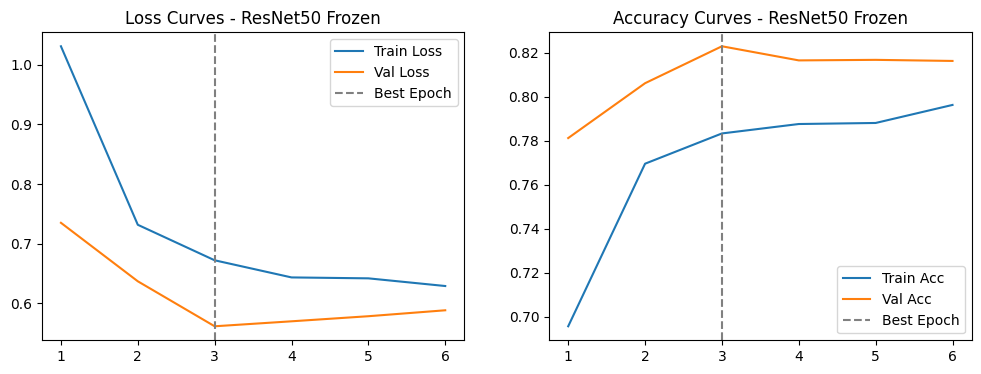

In [35]:
plot_train_curves(results_resnet50_frozen, "ResNet50 Frozen")

In [33]:
efficientnetb0 = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
)
in_features = efficientnetb0.classifier[1].in_features
efficientnetb0.classifier[1] = nn.Linear(in_features, num_classes)
efficientnetb0 = efficientnetb0.to(device)
summary(efficientnetb0, input_size=(1, 3, 64, 64), device=device)

Layer (type:depth-idx)                                  Output Shape              Param #
EfficientNet                                            [1, 10]                   --
├─Sequential: 1-1                                       [1, 1280, 2, 2]           --
│    └─Conv2dNormActivation: 2-1                        [1, 32, 32, 32]           --
│    │    └─Conv2d: 3-1                                 [1, 32, 32, 32]           864
│    │    └─BatchNorm2d: 3-2                            [1, 32, 32, 32]           64
│    │    └─SiLU: 3-3                                   [1, 32, 32, 32]           --
│    └─Sequential: 2-2                                  [1, 16, 32, 32]           --
│    │    └─MBConv: 3-4                                 [1, 16, 32, 32]           1,448
│    └─Sequential: 2-3                                  [1, 24, 16, 16]           --
│    │    └─MBConv: 3-5                                 [1, 24, 16, 16]           6,004
│    │    └─MBConv: 3-6                              

In [36]:
reproducibility()

efficientnetb0 = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
)
in_features = efficientnetb0.classifier[1].in_features
efficientnetb0.classifier[1] = nn.Linear(in_features, num_classes)
efficientnetb0 = efficientnetb0.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(efficientnetb0.parameters(), 1e-3)

results_efficientnetb0 = train_model(
    model=efficientnetb0,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=15,
)

Random seed set to 42
Epoch 1/15 | Train Loss: 0.5157, Train Acc: 0.8402 | Val Loss: 0.2365, Val Acc: 0.9301
Epoch 2/15 | Train Loss: 0.2721, Train Acc: 0.9133 | Val Loss: 0.2361, Val Acc: 0.9185
Epoch 3/15 | Train Loss: 0.2157, Train Acc: 0.9297 | Val Loss: 0.1989, Val Acc: 0.9252
Epoch 4/15 | Train Loss: 0.1990, Train Acc: 0.9342 | Val Loss: 0.1162, Val Acc: 0.9657
Epoch 5/15 | Train Loss: 0.1761, Train Acc: 0.9423 | Val Loss: 0.1477, Val Acc: 0.9459
Epoch 6/15 | Train Loss: 0.1754, Train Acc: 0.9429 | Val Loss: 0.2102, Val Acc: 0.9316
Epoch 7/15 | Train Loss: 0.1589, Train Acc: 0.9486 | Val Loss: 0.1558, Val Acc: 0.9528
Early stopping triggered at epoch 7 (best val loss: 0.1162)
Test Accuracy: 95.88%
Training Time: 4.29 minutes


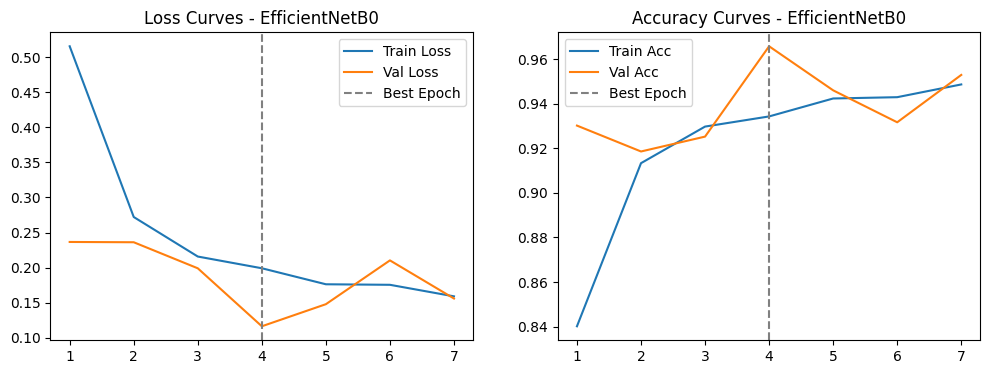

In [37]:
plot_train_curves(results_efficientnetb0, "EfficientNetB0")

In [34]:
efficientnetb0_frozen = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
)
for param in efficientnetb0_frozen.parameters():
    param.requires_grad = False
in_features = efficientnetb0_frozen.classifier[1].in_features
efficientnetb0_frozen.classifier[1] = nn.Linear(in_features, num_classes)
efficientnetb0_frozen = efficientnetb0_frozen.to(device)
summary(efficientnetb0_frozen, input_size=(1, 3, 64, 64), device=device)

Layer (type:depth-idx)                                  Output Shape              Param #
EfficientNet                                            [1, 10]                   --
├─Sequential: 1-1                                       [1, 1280, 2, 2]           --
│    └─Conv2dNormActivation: 2-1                        [1, 32, 32, 32]           --
│    │    └─Conv2d: 3-1                                 [1, 32, 32, 32]           (864)
│    │    └─BatchNorm2d: 3-2                            [1, 32, 32, 32]           (64)
│    │    └─SiLU: 3-3                                   [1, 32, 32, 32]           --
│    └─Sequential: 2-2                                  [1, 16, 32, 32]           --
│    │    └─MBConv: 3-4                                 [1, 16, 32, 32]           (1,448)
│    └─Sequential: 2-3                                  [1, 24, 16, 16]           --
│    │    └─MBConv: 3-5                                 [1, 24, 16, 16]           (6,004)
│    │    └─MBConv: 3-6                      

In [39]:
reproducibility()

efficientnetb0_frozen = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
)
for param in efficientnetb0_frozen.parameters():
    param.requires_grad = False
in_features = efficientnetb0_frozen.classifier[1].in_features
efficientnetb0_frozen.classifier[1] = nn.Linear(in_features, num_classes)
efficientnetb0_frozen = efficientnetb0_frozen.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(efficientnetb0_frozen.parameters(), 1e-3)

results_efficientnetb0_frozen = train_model(
    model=efficientnetb0_frozen,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=15,
)

Random seed set to 42
Epoch 1/15 | Train Loss: 1.0265, Train Acc: 0.6610 | Val Loss: 0.8521, Val Acc: 0.7183
Epoch 2/15 | Train Loss: 0.8639, Train Acc: 0.7093 | Val Loss: 0.7913, Val Acc: 0.7363
Epoch 3/15 | Train Loss: 0.8459, Train Acc: 0.7132 | Val Loss: 0.8002, Val Acc: 0.7291
Epoch 4/15 | Train Loss: 0.8514, Train Acc: 0.7096 | Val Loss: 0.8117, Val Acc: 0.7259
Epoch 5/15 | Train Loss: 0.8451, Train Acc: 0.7143 | Val Loss: 0.7859, Val Acc: 0.7378
Epoch 6/15 | Train Loss: 0.8481, Train Acc: 0.7142 | Val Loss: 0.7899, Val Acc: 0.7368
Epoch 7/15 | Train Loss: 0.8473, Train Acc: 0.7158 | Val Loss: 0.8022, Val Acc: 0.7333
Epoch 8/15 | Train Loss: 0.8479, Train Acc: 0.7134 | Val Loss: 0.7828, Val Acc: 0.7375
Epoch 9/15 | Train Loss: 0.8505, Train Acc: 0.7147 | Val Loss: 0.7830, Val Acc: 0.7363
Epoch 10/15 | Train Loss: 0.8531, Train Acc: 0.7127 | Val Loss: 0.7961, Val Acc: 0.7316
Epoch 11/15 | Train Loss: 0.8639, Train Acc: 0.7093 | Val Loss: 0.7841, Val Acc: 0.7388
Early stopping trig

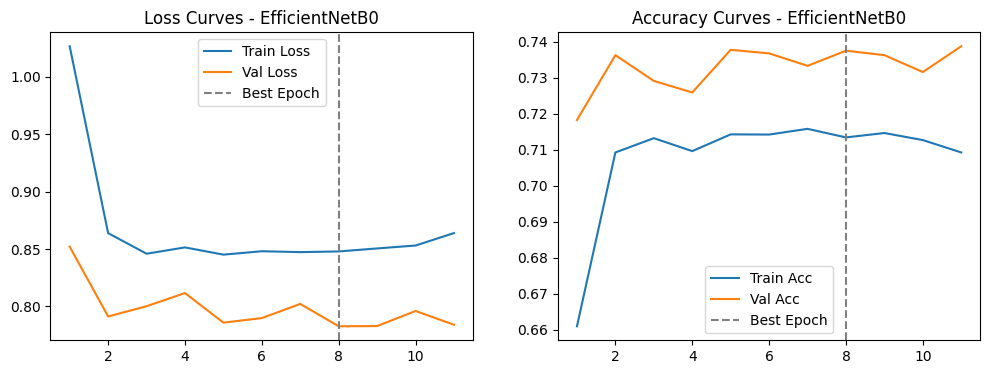

In [40]:
plot_train_curves(results_efficientnetb0_frozen, "EfficientNetB0")

In [11]:
train_transform_vit = transforms.Compose(
    [
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(90),
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

val_test_transform_vit = transforms.Compose(
    [
        transforms.Resize(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

train_full_vit = Subset(
    datasets.EuroSAT(root="./data", transform=train_transform_vit),
    train_full_idx,
)
val_set_vit = Subset(
    datasets.EuroSAT(root="./data", transform=val_test_transform_vit),
    val_idx,
)
test_set_vit = Subset(
    datasets.EuroSAT(root="./data", transform=val_test_transform_vit),
    test_idx,
)

batch_size_vit = 32

train_loader_vit = DataLoader(
    train_full_vit, batch_size=batch_size_vit, shuffle=True, num_workers=2
)
val_loader_vit = DataLoader(
    val_set_vit, batch_size=batch_size_vit, shuffle=False, num_workers=2
)
test_loader_vit = DataLoader(
    test_set_vit, batch_size=batch_size_vit, shuffle=False, num_workers=2
)

In [35]:
vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
in_features = vit.heads.head.in_features
vit.heads.head = nn.Linear(in_features, num_classes)
vit = vit.to(device)
summary(vit, input_size=(1, 3, 224, 224), device=device)

Layer (type:depth-idx)                        Output Shape              Param #
VisionTransformer                             [1, 10]                   768
├─Conv2d: 1-1                                 [1, 768, 14, 14]          590,592
├─Encoder: 1-2                                [1, 197, 768]             151,296
│    └─Dropout: 2-1                           [1, 197, 768]             --
│    └─Sequential: 2-2                        [1, 197, 768]             --
│    │    └─EncoderBlock: 3-1                 [1, 197, 768]             7,087,872
│    │    └─EncoderBlock: 3-2                 [1, 197, 768]             7,087,872
│    │    └─EncoderBlock: 3-3                 [1, 197, 768]             7,087,872
│    │    └─EncoderBlock: 3-4                 [1, 197, 768]             7,087,872
│    │    └─EncoderBlock: 3-5                 [1, 197, 768]             7,087,872
│    │    └─EncoderBlock: 3-6                 [1, 197, 768]             7,087,872
│    │    └─EncoderBlock: 3-7             

In [ ]:
reproducibility()

vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
in_features = vit.heads.head.in_features
vit.heads.head = nn.Linear(in_features, num_classes)
vit = vit.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(vit.parameters(), 3e-4)

results_vit = train_model(
    model=vit,
    train_loader=train_loader_vit,
    val_loader=val_loader_vit,
    test_loader=test_loader_vit,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=10,
)

Random seed set to 42
Epoch 1/15 | Train Loss: 0.4433, Train Acc: 0.8486 | Val Loss: 0.3301, Val Acc: 0.8970
Epoch 2/15 | Train Loss: 0.2428, Train Acc: 0.9171 | Val Loss: 0.2201, Val Acc: 0.9183
Epoch 3/15 | Train Loss: 0.2086, Train Acc: 0.9295 | Val Loss: 0.1534, Val Acc: 0.9499
Epoch 4/15 | Train Loss: 0.1852, Train Acc: 0.9358 | Val Loss: 0.1318, Val Acc: 0.9533
Epoch 5/15 | Train Loss: 0.1616, Train Acc: 0.9458 | Val Loss: 0.2065, Val Acc: 0.9301
Epoch 6/15 | Train Loss: 0.1592, Train Acc: 0.9462 | Val Loss: 0.1224, Val Acc: 0.9588
Epoch 7/15 | Train Loss: 0.1464, Train Acc: 0.9498 | Val Loss: 0.1233, Val Acc: 0.9595
Epoch 8/15 | Train Loss: 0.1389, Train Acc: 0.9515 | Val Loss: 0.2497, Val Acc: 0.9205
Epoch 9/15 | Train Loss: 0.1411, Train Acc: 0.9525 | Val Loss: 0.1302, Val Acc: 0.9563
Early stopping triggered at epoch 9 (best val loss: 0.1224)
Test Accuracy: 95.43%
Training Time: 119.61 minutes


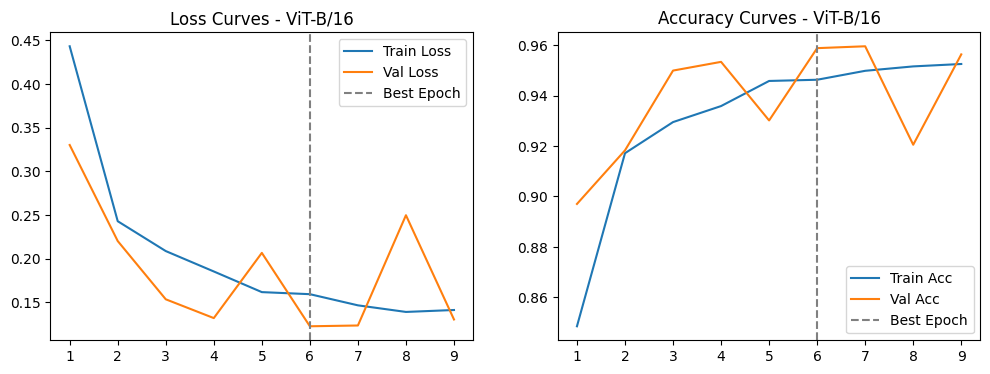

In [21]:
plot_train_curves(results_vit, "ViT-B/16")

In [36]:
vit_frozen = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
in_features = vit_frozen.heads.head.in_features
vit_frozen.heads.head = nn.Linear(in_features, num_classes)
for param in vit_frozen.parameters():
    param.requires_grad = False
for param in vit_frozen.heads.parameters():
    param.requires_grad = True
vit_frozen = vit_frozen.to(device)
summary(vit_frozen, input_size=(1, 3, 224, 224), device=device)

Layer (type:depth-idx)                        Output Shape              Param #
VisionTransformer                             [1, 10]                   768
├─Conv2d: 1-1                                 [1, 768, 14, 14]          (590,592)
├─Encoder: 1-2                                [1, 197, 768]             151,296
│    └─Dropout: 2-1                           [1, 197, 768]             --
│    └─Sequential: 2-2                        [1, 197, 768]             --
│    │    └─EncoderBlock: 3-1                 [1, 197, 768]             (7,087,872)
│    │    └─EncoderBlock: 3-2                 [1, 197, 768]             (7,087,872)
│    │    └─EncoderBlock: 3-3                 [1, 197, 768]             (7,087,872)
│    │    └─EncoderBlock: 3-4                 [1, 197, 768]             (7,087,872)
│    │    └─EncoderBlock: 3-5                 [1, 197, 768]             (7,087,872)
│    │    └─EncoderBlock: 3-6                 [1, 197, 768]             (7,087,872)
│    │    └─EncoderBlock: 3-

In [13]:
reproducibility()

vit_frozen = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
in_features = vit_frozen.heads.head.in_features
vit_frozen.heads.head = nn.Linear(in_features, num_classes)
for param in vit_frozen.parameters():
    param.requires_grad = False
for param in vit_frozen.heads.parameters():
    param.requires_grad = True
vit_frozen = vit_frozen.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(vit_frozen.parameters(), 1e-3)

results_vit_frozen = train_model(
    model=vit_frozen,
    train_loader=train_loader_vit,
    val_loader=val_loader_vit,
    test_loader=test_loader_vit,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=15,
)

Random seed set to 42
Epoch 1/15 | Train Loss: 0.4456, Train Acc: 0.8754 | Val Loss: 0.3150, Val Acc: 0.8973
Epoch 2/15 | Train Loss: 0.2218, Train Acc: 0.9310 | Val Loss: 0.2209, Val Acc: 0.9257
Epoch 3/15 | Train Loss: 0.1820, Train Acc: 0.9411 | Val Loss: 0.1923, Val Acc: 0.9346
Epoch 4/15 | Train Loss: 0.1651, Train Acc: 0.9452 | Val Loss: 0.1925, Val Acc: 0.9304
Epoch 5/15 | Train Loss: 0.1523, Train Acc: 0.9494 | Val Loss: 0.1718, Val Acc: 0.9365
Epoch 6/15 | Train Loss: 0.1458, Train Acc: 0.9512 | Val Loss: 0.1604, Val Acc: 0.9417
Epoch 7/15 | Train Loss: 0.1384, Train Acc: 0.9539 | Val Loss: 0.1572, Val Acc: 0.9432
Epoch 8/15 | Train Loss: 0.1321, Train Acc: 0.9552 | Val Loss: 0.1609, Val Acc: 0.9432
Epoch 9/15 | Train Loss: 0.1261, Train Acc: 0.9567 | Val Loss: 0.1557, Val Acc: 0.9444
Epoch 10/15 | Train Loss: 0.1250, Train Acc: 0.9586 | Val Loss: 0.1493, Val Acc: 0.9464
Epoch 11/15 | Train Loss: 0.1239, Train Acc: 0.9589 | Val Loss: 0.1453, Val Acc: 0.9491
Epoch 12/15 | Train

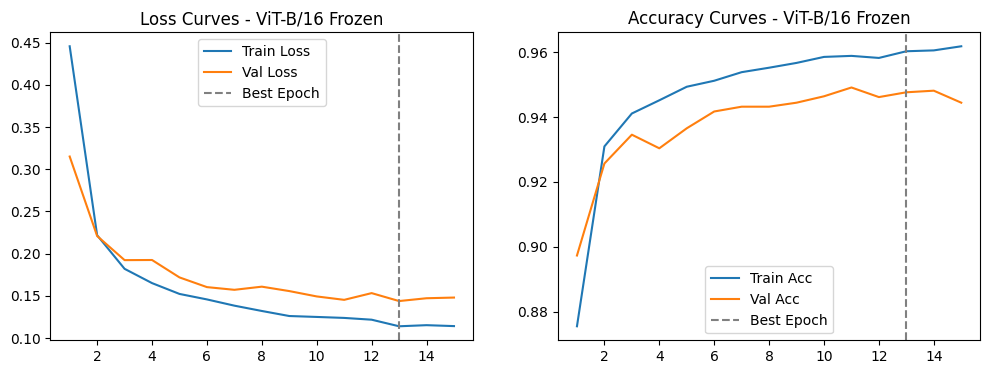

In [14]:
plot_train_curves(results_vit_frozen, "ViT-B/16 Frozen")

### Task 1.3 – Transfer Learning in Few-Shot scenarios


In [33]:
batch_size = 32

train_10shot_loader = DataLoader(
    train_10shot, batch_size=batch_size, shuffle=True, num_workers=2
)

train_5shot_loader = DataLoader(
    train_5shot, batch_size=batch_size, shuffle=True, num_workers=2
)

In [14]:
reproducibility()

efficientnetb0_10shot = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
)
in_features = efficientnetb0_10shot.classifier[1].in_features
efficientnetb0_10shot.classifier[1] = nn.Linear(in_features, num_classes)
efficientnetb0_10shot = efficientnetb0_10shot.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(efficientnetb0_10shot.parameters(), 1e-3)

results_efficientnetb0_10shot = train_model(
    model=efficientnetb0_10shot,
    train_loader=train_10shot_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=4,
)

Random seed set to 42
Epoch 1/4 | Train Loss: 2.2954, Train Acc: 0.1400 | Val Loss: 2.0969, Val Acc: 0.3679
Epoch 2/4 | Train Loss: 1.8467, Train Acc: 0.3900 | Val Loss: 1.7698, Val Acc: 0.5314
Epoch 3/4 | Train Loss: 1.3752, Train Acc: 0.6500 | Val Loss: 1.4046, Val Acc: 0.6104
Epoch 4/4 | Train Loss: 1.1010, Train Acc: 0.6400 | Val Loss: 1.1481, Val Acc: 0.6437
Test Accuracy: 63.16%
Training Time: 0.26 minutes


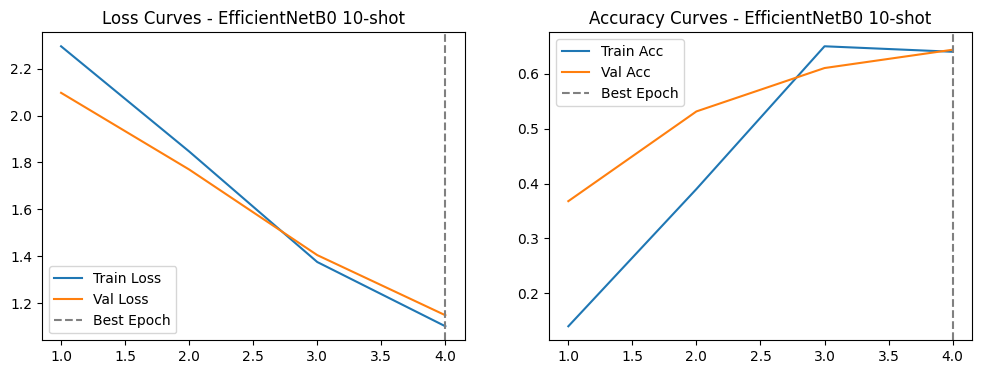

In [29]:
plot_train_curves(results_efficientnetb0_10shot, "EfficientNetB0 10-shot")

In [16]:
reproducibility()

efficientnetb0_5shot = models.efficientnet_b0(
    weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1
)
in_features = efficientnetb0_5shot.classifier[1].in_features
efficientnetb0_5shot.classifier[1] = nn.Linear(in_features, num_classes)
efficientnetb0_5shot = efficientnetb0_5shot.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(efficientnetb0_5shot.parameters(), 1e-3)

results_efficientnetb0_5shot = train_model(
    model=efficientnetb0_5shot,
    train_loader=train_5shot_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=4,
)

Random seed set to 42
Epoch 1/4 | Train Loss: 2.3227, Train Acc: 0.1200 | Val Loss: 2.2195, Val Acc: 0.2546
Epoch 2/4 | Train Loss: 1.9758, Train Acc: 0.4400 | Val Loss: 2.0973, Val Acc: 0.3267
Epoch 3/4 | Train Loss: 1.6811, Train Acc: 0.5800 | Val Loss: 1.9415, Val Acc: 0.4237
Epoch 4/4 | Train Loss: 1.5591, Train Acc: 0.5400 | Val Loss: 1.7414, Val Acc: 0.5170
Test Accuracy: 52.02%
Training Time: 0.22 minutes


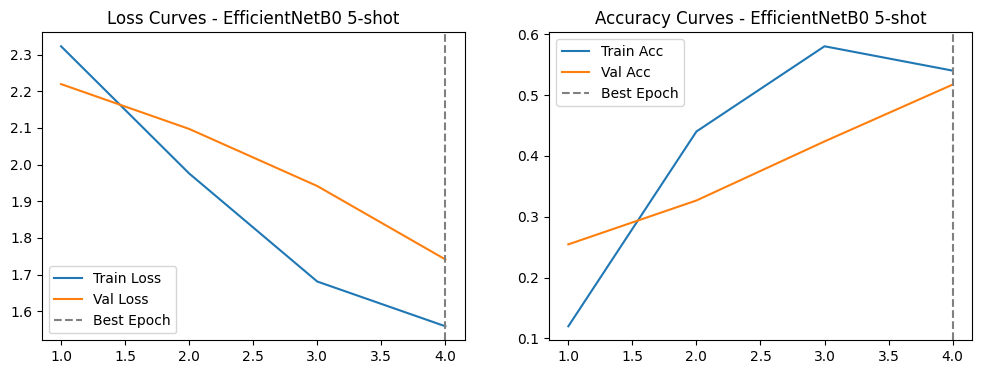

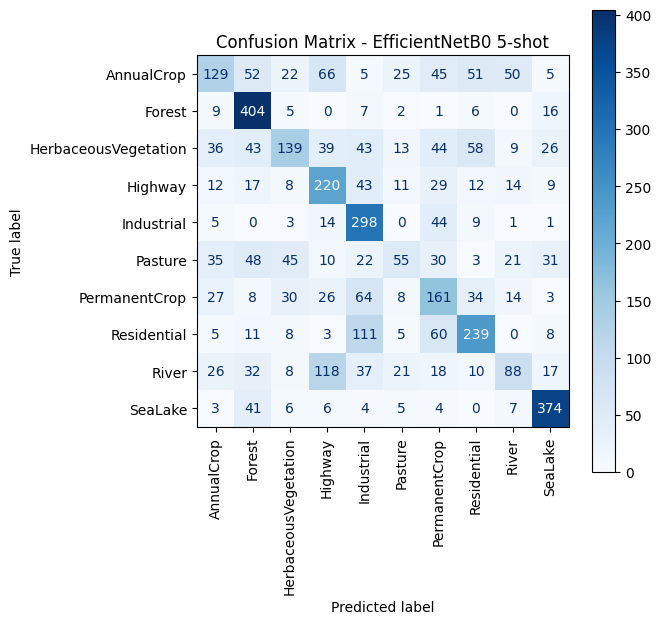

In [27]:
plot_train_curves(results_efficientnetb0_5shot, "EfficientNetB0 5-shot")
plot_confusion_matrix(
    results_efficientnetb0_5shot["confusion_matrix"],
    class_names,
    "EfficientNetB0 5-shot",
)

In [13]:
batch_size_vit = 32

train_10shot_vit = Subset(
    datasets.EuroSAT(root="./data", transform=train_transform_vit),
    train_10shot_idx,
)

train_loader_vit_10shot = DataLoader(
    train_10shot_vit, batch_size=batch_size_vit, shuffle=True, num_workers=2
)

train_5shot_vit = Subset(
    datasets.EuroSAT(root="./data", transform=train_transform_vit),
    train_5shot_idx,
)

train_loader_vit_5shot = DataLoader(
    train_5shot_vit, batch_size=batch_size_vit, shuffle=True, num_workers=2
)

In [35]:
reproducibility()

vit_10shot = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
in_features = vit_10shot.heads.head.in_features
vit_10shot.heads.head = nn.Linear(in_features, num_classes)
vit_10shot = vit_10shot.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(vit_10shot.parameters(), 3e-4)

results_vit_10shot = train_model(
    model=vit_10shot,
    train_loader=train_loader_vit_10shot,
    val_loader=val_loader_vit,
    test_loader=test_loader_vit,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=10,
)

Random seed set to 42
Epoch 1/10 | Train Loss: 2.6586, Train Acc: 0.1000 | Val Loss: 2.3868, Val Acc: 0.1111
Epoch 2/10 | Train Loss: 2.3042, Train Acc: 0.1400 | Val Loss: 2.0843, Val Acc: 0.2299
Epoch 3/10 | Train Loss: 2.1171, Train Acc: 0.2200 | Val Loss: 1.9353, Val Acc: 0.3568
Epoch 4/10 | Train Loss: 1.8046, Train Acc: 0.4000 | Val Loss: 1.8229, Val Acc: 0.3526
Epoch 5/10 | Train Loss: 1.6651, Train Acc: 0.3900 | Val Loss: 1.7260, Val Acc: 0.3373
Epoch 6/10 | Train Loss: 1.5701, Train Acc: 0.3700 | Val Loss: 1.5802, Val Acc: 0.4296
Epoch 7/10 | Train Loss: 1.4866, Train Acc: 0.4800 | Val Loss: 1.5914, Val Acc: 0.4094
Epoch 8/10 | Train Loss: 1.3178, Train Acc: 0.4900 | Val Loss: 1.7383, Val Acc: 0.3546
Epoch 9/10 | Train Loss: 1.3583, Train Acc: 0.5000 | Val Loss: 1.7213, Val Acc: 0.3595
Early stopping triggered at epoch 9 (best val loss: 1.5802)
Test Accuracy: 42.79%
Training Time: 7.51 minutes


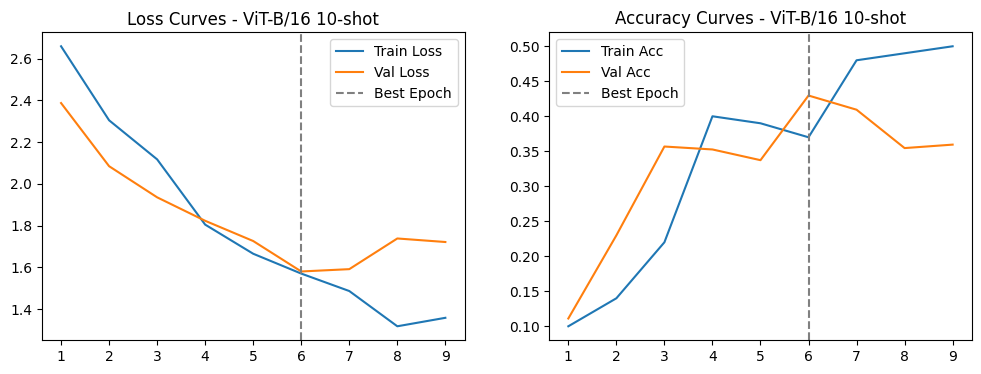

In [ ]:
plot_train_curves(results_vit_10shot, "ViT-B/16 10-shot")

In [32]:
reproducibility()

vit_5shot = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
in_features = vit_5shot.heads.head.in_features
vit_5shot.heads.head = nn.Linear(in_features, num_classes)
vit_5shot = vit_5shot.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(vit_5shot.parameters(), 3e-4)

results_vit_5shot = train_model(
    model=vit_5shot,
    train_loader=train_loader_vit_5shot,
    val_loader=val_loader_vit,
    test_loader=test_loader_vit,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=10,
)

Random seed set to 42
Epoch 1/10 | Train Loss: 2.9929, Train Acc: 0.0000 | Val Loss: 2.2639, Val Acc: 0.2106
Epoch 2/10 | Train Loss: 2.3302, Train Acc: 0.1800 | Val Loss: 2.0959, Val Acc: 0.2881
Epoch 3/10 | Train Loss: 2.1298, Train Acc: 0.3200 | Val Loss: 2.0333, Val Acc: 0.2521
Epoch 4/10 | Train Loss: 1.9645, Train Acc: 0.2600 | Val Loss: 1.8874, Val Acc: 0.3040
Epoch 5/10 | Train Loss: 1.7935, Train Acc: 0.3200 | Val Loss: 1.8089, Val Acc: 0.3370
Epoch 6/10 | Train Loss: 1.6722, Train Acc: 0.3600 | Val Loss: 1.8611, Val Acc: 0.3615
Epoch 7/10 | Train Loss: 1.5084, Train Acc: 0.4800 | Val Loss: 1.7366, Val Acc: 0.3351
Epoch 8/10 | Train Loss: 1.4501, Train Acc: 0.4200 | Val Loss: 1.6401, Val Acc: 0.4116
Epoch 9/10 | Train Loss: 1.2432, Train Acc: 0.5600 | Val Loss: 1.6394, Val Acc: 0.3901
Epoch 10/10 | Train Loss: 1.1462, Train Acc: 0.6400 | Val Loss: 1.6134, Val Acc: 0.4126
Test Accuracy: 39.83%
Training Time: 7.90 minutes


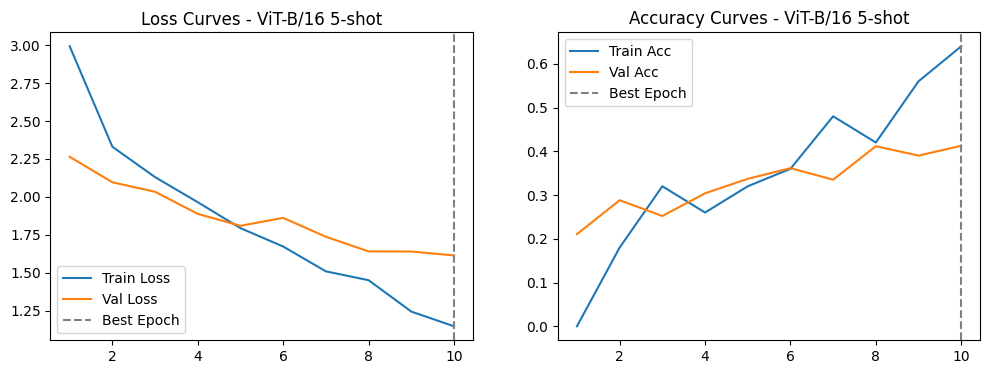

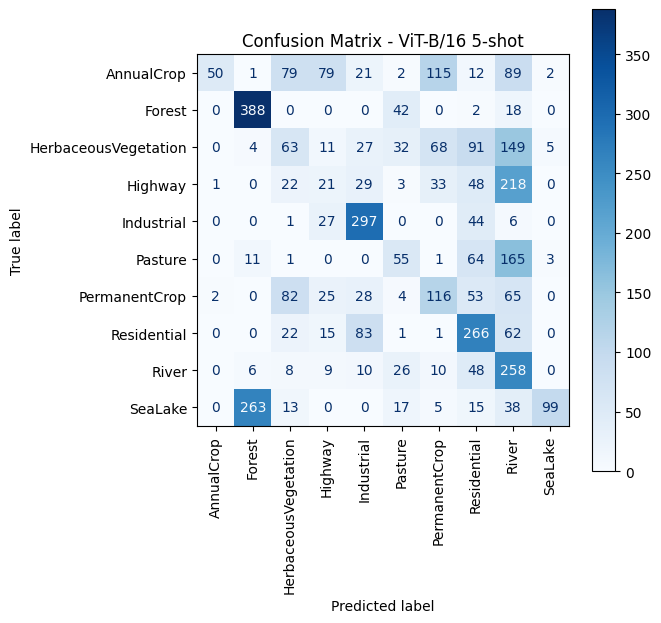

In [33]:
plot_train_curves(results_vit_5shot, "ViT-B/16 5-shot")
plot_confusion_matrix(
    results_vit_5shot["confusion_matrix"],
    class_names,
    "ViT-B/16 5-shot",
)

## 2 – Few-Shot and Zero-Shot Learning


### Task 2.1 – Prototype-based Few-Shot Classifier


In [14]:
def extract_embeddings(model, loader):
    embeddings = []
    labels = []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            feats = model(x)
            embeddings.append(feats.cpu())
            labels.append(y)

    return torch.cat(embeddings), torch.cat(labels)


def compute_prototypes(embeddings, labels, num_classes):
    prototypes = []

    for i in range(num_classes):
        class_embeddings = embeddings[labels == i]
        prototype = class_embeddings.mean(dim=0)
        prototypes.append(prototype)

    return torch.stack(prototypes)


def prototype_classify(test_embeddings, prototypes, metric="euclidean"):
    if metric == "euclidean":
        dists = torch.cdist(test_embeddings, prototypes)
        preds = dists.argmin(dim=1)
    elif metric == "cosine":
        test_norm = F.normalize(test_embeddings, dim=1)
        proto_norm = F.normalize(prototypes, dim=1)
        sims = test_norm @ proto_norm.T
        preds = sims.argmax(dim=1)
    else:
        raise ValueError("Metric must be euclidean or cosine.")

    return preds


def evaluate_few_shot(loader, test_loader, encoder, num_classes, metric="euclidean"):
    embeddings, labels = extract_embeddings(encoder, loader)
    test_embeddings, test_labels = extract_embeddings(encoder, test_loader)
    prototypes = compute_prototypes(embeddings, labels, num_classes)
    preds = prototype_classify(test_embeddings, prototypes, metric)
    acc = (preds == test_labels).float().mean().item()

    return acc

In [49]:
reproducibility()

batch_size = 16

support_10shot_loader = DataLoader(
    train_10shot, batch_size=batch_size, shuffle=False, num_workers=2
)

support_5shot_loader = DataLoader(
    train_5shot, batch_size=batch_size, shuffle=False, num_workers=2
)

test_loader_proto = DataLoader(
    test_set, batch_size=batch_size, shuffle=False, num_workers=2
)

encoder = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
encoder.fc = nn.Identity()
for param in encoder.parameters():
    param.requires_grad = False
encoder = encoder.to(device)
encoder.eval()

acc_10shot_euc = evaluate_few_shot(
    support_10shot_loader,
    test_loader_proto,
    encoder,
    num_classes,
    metric="euclidean",
)

acc_10shot_cos = evaluate_few_shot(
    support_10shot_loader,
    test_loader_proto,
    encoder,
    num_classes,
    metric="cosine",
)

acc_5shot_euc = evaluate_few_shot(
    support_5shot_loader,
    test_loader_proto,
    encoder,
    num_classes,
    metric="euclidean",
)

acc_5shot_cos = evaluate_few_shot(
    support_5shot_loader,
    test_loader_proto,
    encoder,
    num_classes,
    metric="cosine",
)

print(f"10-shot Euclidean Accuracy: {acc_10shot_euc*100:.2f}%")
print(f"10-shot Cosine Accuracy: {acc_10shot_cos*100:.2f}%")

print(f"5-shot Euclidean Accuracy: {acc_5shot_euc*100:.2f}%")
print(f"5-shot Cosine Accuracy: {acc_5shot_cos*100:.2f}%")

Random seed set to 42
10-shot Euclidean Accuracy: 58.30%
10-shot Cosine Accuracy: 57.63%
5-shot Euclidean Accuracy: 38.05%
5-shot Cosine Accuracy: 44.59%


### Task 2.2 – Zero-Shot Learning with CLIP


In [34]:
def clip_collate_fn(batch):
    images, labels = zip(*batch)
    return list(images), torch.tensor(labels)


test_set_clip = Subset(
    datasets.EuroSAT(root="./data", transform=None),
    test_idx,
)

batch_size_clip = 32

test_loader_clip = DataLoader(
    test_set_clip,
    batch_size=batch_size_clip,
    shuffle=False,
    num_workers=2,
    collate_fn=clip_collate_fn,
)

In [35]:
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
clip_model = clip_model.to(device)
clip_model.eval()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIPModel(
  (text_model): CLIPTextTransformer(
    (embeddings): CLIPTextEmbeddings(
      (token_embedding): Embedding(49408, 512)
      (position_embedding): Embedding(77, 512)
    )
    (encoder): CLIPEncoder(
      (layers): ModuleList(
        (0-11): 12 x CLIPEncoderLayer(
          (self_attn): CLIPAttention(
            (k_proj): Linear(in_features=512, out_features=512, bias=True)
            (v_proj): Linear(in_features=512, out_features=512, bias=True)
            (q_proj): Linear(in_features=512, out_features=512, bias=True)
            (out_proj): Linear(in_features=512, out_features=512, bias=True)
          )
          (layer_norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (mlp): CLIPMLP(
            (activation_fn): QuickGELUActivation()
            (fc1): Linear(in_features=512, out_features=2048, bias=True)
            (fc2): Linear(in_features=2048, out_features=512, bias=True)
          )
          (layer_norm2): LayerNorm((512,), eps=1e-05,

In [15]:
basic_prompt = ["a satellite image of {}"]
domain_prompts = [
    "an aerial view of {} terrain",
    "a satellite photograph showing {} land use",
    "top-down view of {} area",
]


def encode_text(prompts):
    text_inputs = clip_processor(text=prompts, padding=True, return_tensors="pt").to(
        device
    )

    with torch.no_grad():
        text_features = clip_model.get_text_features(**text_inputs)

    text_features = F.normalize(text_features, dim=1)
    return text_features


def build_zeroshot_classifier(prompt_templates, class_names):
    all_embeddings = []

    for template in prompt_templates:
        prompts = [template.format(c) for c in class_names]
        text_emb = encode_text(prompts)
        all_embeddings.append(text_emb)

    zeroshot_weights = torch.stack(all_embeddings).mean(dim=0)
    zeroshot_weights = F.normalize(zeroshot_weights, dim=-1)

    return zeroshot_weights


def clip_zeroshot_eval(dataloader, zeroshot_weights):
    correct = 0
    total = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in dataloader:
            labels = labels.to(device)

            image_inputs = clip_processor(images=images, return_tensors="pt").to(device)
            image_inputs.to(device)

            image_features = clip_model.get_image_features(**image_inputs)
            image_features = F.normalize(image_features, dim=-1)

            logits = image_features @ zeroshot_weights.T
            preds = logits.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

    acc = correct / total
    return acc, torch.cat(all_preds), torch.cat(all_labels)


def per_class_accuracy(y_true, y_pred, class_names):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    accs = {}
    for i, c in enumerate(class_names):
        mask = y_true == i
        acc = (y_pred[mask] == i).mean() if mask.sum() > 0 else 0.0
        accs[c] = acc

    return accs

In [37]:
results_clip = {}

weights_basic = build_zeroshot_classifier(basic_prompt, class_names)
acc_basic, _, _ = clip_zeroshot_eval(test_loader_clip, weights_basic)
results_clip["Basic prompt"] = acc_basic

for i, p in enumerate(domain_prompts):
    weights = build_zeroshot_classifier([p], class_names)
    acc, _, _ = clip_zeroshot_eval(test_loader_clip, weights)
    results_clip[f"Domain prompt {i+1}"] = acc

weights_ensemble = build_zeroshot_classifier(basic_prompt + domain_prompts, class_names)
acc_ensemble, preds_clip, labels_clip = clip_zeroshot_eval(
    test_loader_clip, weights_ensemble
)
results_clip["Ensemble"] = acc_ensemble

for k, v in results_clip.items():
    print(f"{k:<20} : {v*100:.2f}%")

Basic prompt         : 39.60%
Domain prompt 1      : 32.57%
Domain prompt 2      : 42.57%
Domain prompt 3      : 32.64%
Ensemble             : 37.58%


CLIP Zero-Shot Per-Class Accuracy (Ensemble):

Residential            : 86.89%
Industrial             : 67.20%
Highway                : 63.20%
River                  : 52.53%
Forest                 : 44.00%
PermanentCrop          : 34.13%
AnnualCrop             : 15.11%
SeaLake                : 9.56%
Pasture                : 2.67%
HerbaceousVegetation   : 0.00%


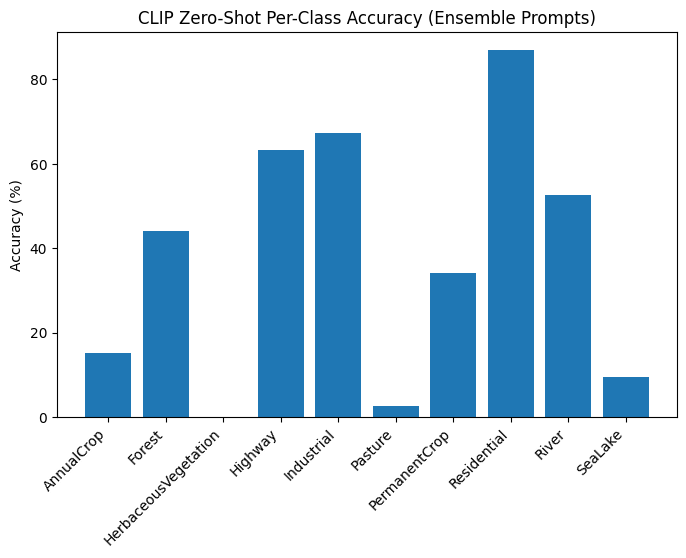

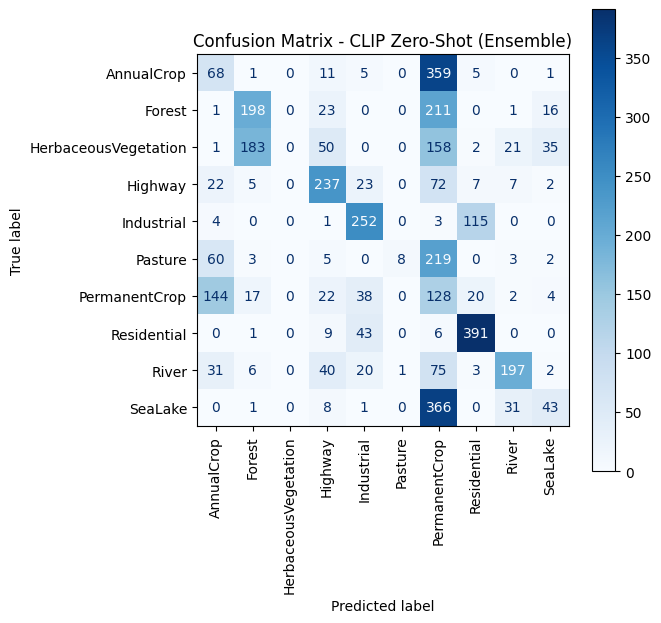

In [43]:
class_acc_clip = per_class_accuracy(
    labels_clip.numpy(), preds_clip.numpy(), class_names
)

print("CLIP Zero-Shot Per-Class Accuracy (Ensemble):\n")

for c, acc in sorted(class_acc_clip.items(), key=lambda x: x[1], reverse=True):
    print(f"{c:<22} : {acc*100:.2f}%")

plt.figure(figsize=(8, 5))
plt.bar(class_acc_clip.keys(), [v * 100 for v in class_acc_clip.values()])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy (%)")
plt.title("CLIP Zero-Shot Per-Class Accuracy (Ensemble Prompts)")
plt.show()

cm = confusion_matrix(labels_clip.numpy(), preds_clip.numpy())
plot_confusion_matrix(cm, class_names, "CLIP Zero-Shot (Ensemble)")

## 3: Self-Supervised Learning (SimCLR)


In [15]:
transform_simclr = transforms.Compose(
    [
        transforms.RandomResizedCrop(64, scale=(0.2, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.ColorJitter(0.4, 0.4, 0.4, 0.1),
        transforms.GaussianBlur(kernel_size=9),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)


class SimCLRDataset(Dataset):
    def __init__(self, base_dataset, transform):
        self.dataset = base_dataset
        self.transform = transform

    def __getitem__(self, index):
        image, _ = self.dataset[index]
        xi = self.transform(image)
        xj = self.transform(image)
        return xi, xj

    def __len__(self):
        return len(self.dataset)


class SimCLR(nn.Module):
    def __init__(self, backbone="resnet18", proj_dim=128):
        super().__init__()

        if backbone == "resnet18":
            encoder = models.resnet18(weights=None)
        else:
            encoder = models.resnet34(weights=None)

        self.encoder = encoder
        self.feature_dim = encoder.fc.in_features
        self.encoder.fc = nn.Identity()
        self.projection_head = nn.Sequential(
            nn.Linear(self.feature_dim, self.feature_dim),
            nn.ReLU(),
            nn.Linear(self.feature_dim, proj_dim),
        )

    def forward(self, x):
        h = self.encoder(x)
        z = self.projection_head(h)
        return F.normalize(z, dim=1)

In [16]:
def nt_xent_loss(z_i, z_j, temperature=0.07):
    N = z_i.size(0)
    z = torch.cat([z_i, z_j], dim=0)
    sim = torch.matmul(z, z.T) / temperature
    mask = torch.eye(2 * N, dtype=torch.bool, device=z.device)
    sim = sim.masked_fill(mask, -1e9)
    pos = torch.cat([sim.diag(N), sim.diag(-N)], dim=0)
    numerator = torch.exp(pos)
    denominator = torch.sum(torch.exp(sim), dim=1)

    return -torch.log(numerator / denominator).mean()


def pretrain_simclr(model, loader, optimizer, epochs=40):
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for x1, x2 in loader:
            x1, x2 = x1.to(device), x2.to(device)
            z1 = model(x1)
            z2 = model(x2)
            loss = nt_xent_loss(z1, z2)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(loader):.4f}")

In [38]:
reproducibility()

eurosat_data_simclr = datasets.EuroSAT(root="./data", download=True, transform=None)

simclr_dataset = SimCLRDataset(eurosat_data_simclr, transform_simclr)

simclr_loader = DataLoader(
    simclr_dataset, batch_size=128, shuffle=True, num_workers=2, drop_last=True
)
simclr_model = SimCLR(backbone="resnet34").to(device)

optimizer = torch.optim.Adam(simclr_model.parameters(), lr=3e-4)

pretrain_simclr(simclr_model, simclr_loader, optimizer, epochs=50)

Random seed set to 42
Epoch 1/50 | Loss: 4.0397
Epoch 2/50 | Loss: 3.3287
Epoch 3/50 | Loss: 3.0418
Epoch 4/50 | Loss: 2.7989
Epoch 5/50 | Loss: 2.5751
Epoch 6/50 | Loss: 2.3935
Epoch 7/50 | Loss: 2.2647
Epoch 8/50 | Loss: 2.1185
Epoch 9/50 | Loss: 1.9940
Epoch 10/50 | Loss: 1.8897
Epoch 11/50 | Loss: 1.7887
Epoch 12/50 | Loss: 1.7433
Epoch 13/50 | Loss: 1.6412
Epoch 14/50 | Loss: 1.5717
Epoch 15/50 | Loss: 1.4861
Epoch 16/50 | Loss: 1.4665
Epoch 17/50 | Loss: 1.4112
Epoch 18/50 | Loss: 1.3589
Epoch 19/50 | Loss: 1.3330
Epoch 20/50 | Loss: 1.2924
Epoch 21/50 | Loss: 1.2404
Epoch 22/50 | Loss: 1.2400
Epoch 23/50 | Loss: 1.1920
Epoch 24/50 | Loss: 1.1688
Epoch 25/50 | Loss: 1.1180
Epoch 26/50 | Loss: 1.1059
Epoch 27/50 | Loss: 1.1049
Epoch 28/50 | Loss: 1.0723
Epoch 29/50 | Loss: 1.0570
Epoch 30/50 | Loss: 1.0308
Epoch 31/50 | Loss: 1.0104
Epoch 32/50 | Loss: 0.9915
Epoch 33/50 | Loss: 0.9863
Epoch 34/50 | Loss: 0.9665
Epoch 35/50 | Loss: 0.9480
Epoch 36/50 | Loss: 0.9459
Epoch 37/50 | L

In [39]:
torch.save(simclr_model.state_dict(), "simclr_resnet34_pretrained.pth")

In [40]:
class LinearEvalModel(nn.Module):
    def __init__(self, encoder, classifier):
        super().__init__()
        self.encoder = encoder
        self.classifier = classifier

    def forward(self, x):
        feats = self.encoder(x)
        return self.classifier(feats)

reproducibility()

simclr_model1 = SimCLR(backbone="resnet34", proj_dim=128).to(device)
simclr_model1.load_state_dict(torch.load("simclr_resnet34_pretrained.pth"))
encoder = simclr_model1.encoder
encoder.eval()

for p in encoder.parameters():
    p.requires_grad = False

classifier = nn.Linear(512, num_classes).to(device)

linear_model = LinearEvalModel(encoder, classifier).to(device)

optimizer = torch.optim.Adam(classifier.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

results_linear_eval = train_model(
    model=linear_model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=20,
    patience=5,
)

Random seed set to 42
Epoch 1/20 | Train Loss: 0.9816, Train Acc: 0.6613 | Val Loss: 0.7209, Val Acc: 0.7440
Epoch 2/20 | Train Loss: 0.8138, Train Acc: 0.7099 | Val Loss: 0.6512, Val Acc: 0.7672
Epoch 3/20 | Train Loss: 0.7911, Train Acc: 0.7204 | Val Loss: 0.6494, Val Acc: 0.7711
Epoch 4/20 | Train Loss: 0.7634, Train Acc: 0.7315 | Val Loss: 0.7127, Val Acc: 0.7565
Epoch 5/20 | Train Loss: 0.7636, Train Acc: 0.7314 | Val Loss: 0.6745, Val Acc: 0.7622
Epoch 6/20 | Train Loss: 0.7517, Train Acc: 0.7307 | Val Loss: 0.5937, Val Acc: 0.7938
Epoch 7/20 | Train Loss: 0.7388, Train Acc: 0.7395 | Val Loss: 0.5510, Val Acc: 0.8091
Epoch 8/20 | Train Loss: 0.7398, Train Acc: 0.7367 | Val Loss: 0.5855, Val Acc: 0.7970
Epoch 9/20 | Train Loss: 0.7328, Train Acc: 0.7420 | Val Loss: 0.6169, Val Acc: 0.7916
Epoch 10/20 | Train Loss: 0.7201, Train Acc: 0.7447 | Val Loss: 0.6169, Val Acc: 0.7847
Epoch 11/20 | Train Loss: 0.7235, Train Acc: 0.7410 | Val Loss: 0.5577, Val Acc: 0.8069
Epoch 12/20 | Train

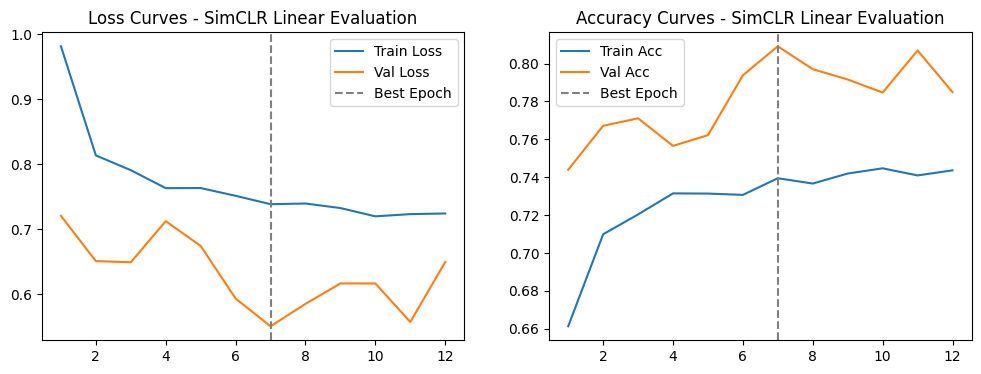

In [41]:
plot_train_curves(results_linear_eval, "SimCLR Linear Evaluation")

In [44]:
class SimCLRFinetuneModel(nn.Module):
    def __init__(self, encoder, num_classes):
        super().__init__()
        self.encoder = encoder
        self.classifier = nn.Linear(512, num_classes)

    def forward(self, x):
        feats = self.encoder(x)
        return self.classifier(feats)

reproducibility()

simclr_model2 = SimCLR(backbone="resnet34", proj_dim=128).to(device)
simclr_model2.load_state_dict(torch.load("simclr_resnet34_pretrained.pth"))
encoder = simclr_model2.encoder

simclr_fine_tune = SimCLRFinetuneModel(encoder, num_classes).to(device)

optimizer = torch.optim.Adam(
    simclr_fine_tune.parameters(), lr=1e-4
)
criterion = nn.CrossEntropyLoss()

results_simclr_full = train_model(
    model=simclr_fine_tune,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=30,
)

Random seed set to 42
Epoch 1/30 | Train Loss: 0.7257, Train Acc: 0.7523 | Val Loss: 0.3820, Val Acc: 0.8662
Epoch 2/30 | Train Loss: 0.4567, Train Acc: 0.8424 | Val Loss: 0.3285, Val Acc: 0.8832
Epoch 3/30 | Train Loss: 0.3915, Train Acc: 0.8647 | Val Loss: 0.3007, Val Acc: 0.9010
Epoch 4/30 | Train Loss: 0.3501, Train Acc: 0.8778 | Val Loss: 0.2631, Val Acc: 0.9101
Epoch 5/30 | Train Loss: 0.3216, Train Acc: 0.8878 | Val Loss: 0.2288, Val Acc: 0.9188
Epoch 6/30 | Train Loss: 0.3029, Train Acc: 0.8951 | Val Loss: 0.2417, Val Acc: 0.9138
Epoch 7/30 | Train Loss: 0.2735, Train Acc: 0.9056 | Val Loss: 0.2170, Val Acc: 0.9259
Epoch 8/30 | Train Loss: 0.2660, Train Acc: 0.9053 | Val Loss: 0.2064, Val Acc: 0.9291
Epoch 9/30 | Train Loss: 0.2554, Train Acc: 0.9119 | Val Loss: 0.2336, Val Acc: 0.9175
Epoch 10/30 | Train Loss: 0.2354, Train Acc: 0.9181 | Val Loss: 0.1958, Val Acc: 0.9301
Epoch 11/30 | Train Loss: 0.2306, Train Acc: 0.9206 | Val Loss: 0.2301, Val Acc: 0.9207
Epoch 12/30 | Train

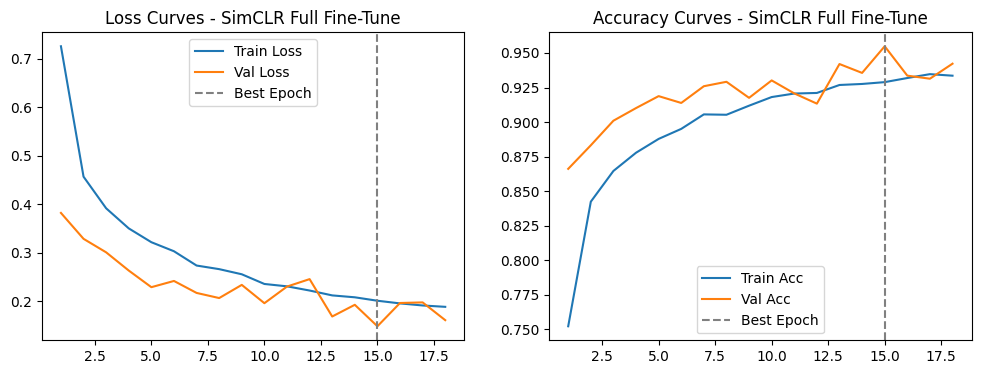

In [45]:
plot_train_curves(results_simclr_full, "SimCLR Full Fine-Tune")

In [56]:
reproducibility()

simclr_model3 = SimCLR(backbone="resnet34", proj_dim=128).to(device)
simclr_model3.load_state_dict(torch.load("simclr_resnet34_pretrained.pth"))
encoder = simclr_model3.encoder

simclr_fine_tune_10shot = SimCLRFinetuneModel(encoder, num_classes).to(device)

optimizer = torch.optim.Adam(
    simclr_fine_tune_10shot.parameters(), lr=5e-5
)
criterion = nn.CrossEntropyLoss()

results_simclr_10shot = train_model(
    model=simclr_fine_tune_10shot,
    train_loader=train_10shot_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    optimizer=optimizer,
    criterion=criterion,
    num_epochs=30,
)

Random seed set to 42
Epoch 1/30 | Train Loss: 2.5682, Train Acc: 0.0500 | Val Loss: 2.4294, Val Acc: 0.0664
Epoch 2/30 | Train Loss: 2.4160, Train Acc: 0.0400 | Val Loss: 2.2999, Val Acc: 0.1272
Epoch 3/30 | Train Loss: 2.3127, Train Acc: 0.0700 | Val Loss: 2.2172, Val Acc: 0.1709
Epoch 4/30 | Train Loss: 2.2077, Train Acc: 0.1800 | Val Loss: 2.1540, Val Acc: 0.2007
Epoch 5/30 | Train Loss: 2.1510, Train Acc: 0.2300 | Val Loss: 2.0741, Val Acc: 0.2378
Epoch 6/30 | Train Loss: 2.0225, Train Acc: 0.2700 | Val Loss: 2.0049, Val Acc: 0.3022
Epoch 7/30 | Train Loss: 1.9739, Train Acc: 0.2800 | Val Loss: 1.9527, Val Acc: 0.3452
Epoch 8/30 | Train Loss: 1.8716, Train Acc: 0.4200 | Val Loss: 1.9015, Val Acc: 0.3849
Epoch 9/30 | Train Loss: 1.8499, Train Acc: 0.4200 | Val Loss: 1.8579, Val Acc: 0.4074
Epoch 10/30 | Train Loss: 1.8002, Train Acc: 0.4600 | Val Loss: 1.8181, Val Acc: 0.4252
Epoch 11/30 | Train Loss: 1.7720, Train Acc: 0.4700 | Val Loss: 1.7871, Val Acc: 0.4306
Epoch 12/30 | Train

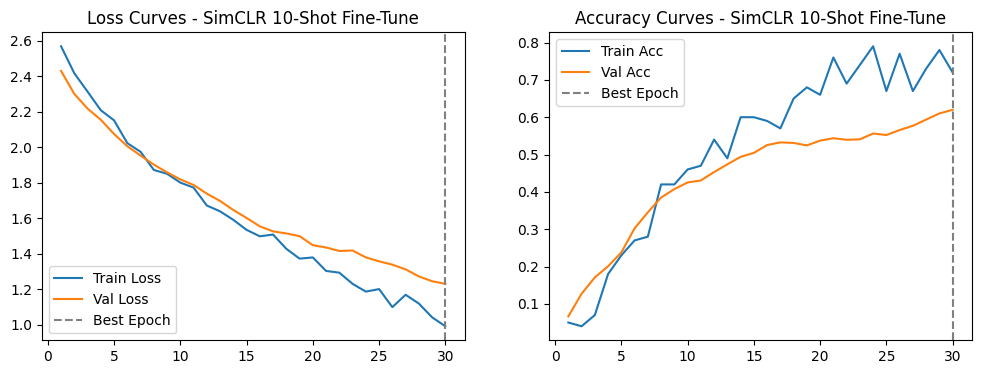

In [57]:
plot_train_curves(results_simclr_10shot, "SimCLR 10-Shot Fine-Tune")